<a href="https://colab.research.google.com/github/thanhthuy280501/Data-Visualization/blob/main/Copy_of_HW4_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')
#please use this cell to read and select your data
import pandas as pd
import plotly.express as px

# 1. Load the dataset
df = pd.read_csv('/content/drive/MyDrive/DATA/olympic_medals.csv')
display(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Gender,Event,Location,Year,Medal,Name,Nationality,Result
0,M,10000M Men,Rio,2016,G,Mohamed FARAH,GBR,25:05.17
1,M,10000M Men,Rio,2016,S,Paul Kipngetich TANUI,KEN,27:05.64
2,M,10000M Men,Rio,2016,B,Tamirat TOLA,ETH,27:06.26
3,M,10000M Men,Beijing,2008,G,Kenenisa BEKELE,ETH,27:01.17
4,M,10000M Men,Beijing,2008,S,Sileshi SIHINE,ETH,27:02.77
...,...,...,...,...,...,...,...,...
2389,W,Triple Jump Women,Athens,2004,S,Hrysopiyi DEVETZI,GRE,15.25
2390,W,Triple Jump Women,Athens,2004,B,Tatyana LEBEDEVA,RUS,15.14
2391,W,Triple Jump Women,Atlanta,1996,G,Inessa KRAVETS,UKR,15.33
2392,W,Triple Jump Women,Atlanta,1996,S,Inna LASOVSKAYA,RUS,14.98


**Q1** Please use Pandas to read olympic_medals.csv and use parallel_categories function from plotly.express to visualize proportions of medal type for each gender from since year 2000. Please see the example in the Python notebook we walked through in the class.

In [19]:
#Please use this cell to create your your figure. Please use Year column to color your graph.
# 2. Filter the data for years since 2000
# Based on common dataset structures, the column is often 'Olympic_year' or 'Year'
# 'Year' as the correct column name
df_since_2000 = df[df['Year'] >= 2000]

# 3. Create the parallel categories diagram
# 'Gender' and 'Medal' are the standard categorical columns
fig = px.parallel_categories(
    df_since_2000,
    dimensions=['Gender', 'Medal'],
    title="Proportion of Medal Types by Gender (Since 2000)"
)

# 4. Display the figure
fig.show()




**Q2** Please inspect the code below and observe how values are plotted by running it. Then, read the 2016elections.csv from the DATA folder and select rows for AR, MI, CA, and WI. Then, utilize stacked bar plot, to stack vote percentages for Trump, Clinton, Johnson, and Others. Please see 'pct_clinton',	'pct_trump',	'pct_johnson',	'pct_other' columns. Make sure that your x tick labels are those four states above.

Text(0.5, 1.0, 'Monthly Temperatures in a year')

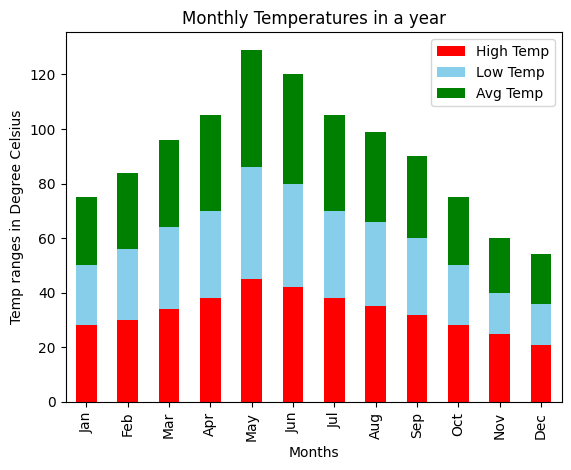

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# create DataFrame
df = pd.DataFrame({'High Temp': [28, 30, 34, 38, 45, 42,
                                 38, 35, 32, 28, 25, 21],
                   'Low Temp': [22, 26, 30, 32, 41, 38,
                                32, 31, 28, 22, 15, 15],
                   'Avg Temp': [25, 28, 32, 35, 43, 40,
                                35, 33, 30, 25, 20, 18]},
                  index=['Jan', 'Feb', 'Mar', 'Apr', 'May',
                         'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
                         'Nov', 'Dec'])


# create stacked bar chart for monthly temperatures
df.plot(kind='bar', stacked=True, color=['red', 'skyblue', 'green'])

# labels for x & y axis
plt.xlabel('Months')
plt.ylabel('Temp ranges in Degree Celsius')

# title of plot
plt.title('Monthly Temperatures in a year')

In [29]:
import pandas as pd
import plotly.express as px

# 1. Read the 2016elections.csv from the DATA folder
df_election = pd.read_csv('/content/drive/MyDrive/DATA/2016elections.csv')

# 2. Select rows for the specific states: AR (Arkansas), MI (Michigan), CA (California), and WI (Wisconsin)
states_to_plot = ['AR', 'MI', 'CA', 'WI']
df_filtered = df_election[df_election['st'].isin(states_to_plot)] # Corrected column from 'state' to 'st'

# 3. Utilize a stacked bar plot to stack vote percentages
#'melt' to transform the columns into a format Plotly can use for stacking
df_melted = df_filtered.melt(
    id_vars=['st'], # Changed 'state' to 'st' here as well for consistency with the x-axis
    value_vars=['pct_clinton', 'pct_trump', 'pct_johnson', 'pct_other'],
    var_name='Candidate',
    value_name='Percentage'
)

# 4. Create the stacked bar chart
fig = px.bar(
    df_melted,
    x='st', # Changed 'state' to 'st' to match the filtered column and requested x-tick labels
    y='Percentage',
    color='Candidate',
    title="2016 Election Vote Percentages by State",
    labels={'st': 'State', 'Percentage': 'Vote %'}, # Changed label key from 'state' to 'st'
    category_orders={"st": states_to_plot} # Changed key from 'state' to 'st'
)

# 5. Display the figure
fig.show()